# 02. Experimental Design: Time Split, Cold-Start Segments, Sample Stability & Bootstrap

**Цель ноутбука:** подготовить корректную экспериментальную схему для сравнения рекомендательных моделей.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path(".")
K = 10

pd.set_option("display.max_columns", 120)

## 1. Загрузка processed-файлов

In [3]:
items_path =  "/content/drive/MyDrive/items_processed.csv"
users_path =  "/content/drive/MyDrive/users_processed.csv"
interactions_path =   "/content/drive/MyDrive/interactions_processed.csv"

print("items:", items_path)
print("users:", users_path)
print("interactions:", interactions_path)

items = pd.read_csv(items_path)
users = pd.read_csv(users_path)
interactions = pd.read_csv(interactions_path, parse_dates=["last_watch_dt"])

print("items:", items.shape)
print("users:", users.shape)
print("interactions:", interactions.shape)

display(items.head())
display(users.head())
display(interactions.head())

items: /content/drive/MyDrive/items_processed.csv
users: /content/drive/MyDrive/users_processed.csv
interactions: /content/drive/MyDrive/interactions_processed.csv
items: (15963, 14)
users: (441316, 5)
interactions: (5476251, 5)


,item_id,content_type,title,title_orig,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,release_year_cat
0,10711,film,поговори с ней,Hable con ella,"драмы, зарубежные, детективы, мелодрамы",испания,False,16.0,unknown,педро альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ...",2000-2010
1,2508,film,голые перцы,Search Party,"зарубежные, приключения, комедии",сша,False,16.0,unknown,скот армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео...",2010-2020
2,10716,film,тактическая сила,Tactical Force,"криминал, зарубежные, триллеры, боевики, комедии",канада,False,16.0,unknown,адам п. калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг...",2010-2020
3,7868,film,45 лет,45 Years,"драмы, зарубежные, мелодрамы",великобритания,False,16.0,unknown,эндрю хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю...",2010-2020
4,16268,film,все решает мгновение,NaN,"драмы, спорт, советские, мелодрамы",ссср,False,12.0,ленфильм,виктор садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж...",1970-1980


,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,M,True
1,962099,age_18_24,income_20_40,M,False
2,1047345,age_45_54,income_40_60,F,False
3,721985,age_45_54,income_20_40,F,False
4,704055,age_35_44,income_60_90,F,False


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72
1,699317,1659,2021-05-29,8317,100
2,656683,7107,2021-05-09,10,0
3,864613,7638,2021-07-05,14483,100
4,964868,9506,2021-04-30,6725,100


## 2. Проверка и минимальная нормализация типов

In [4]:
items["item_id"] = items["item_id"].astype(int)
users["user_id"] = users["user_id"].astype(int)

interactions["user_id"] = interactions["user_id"].astype(int)
interactions["item_id"] = interactions["item_id"].astype(int)

if not np.issubdtype(interactions["last_watch_dt"].dtype, np.datetime64):
    interactions["last_watch_dt"] = pd.to_datetime(interactions["last_watch_dt"])

if "watched_pct" not in interactions.columns:
    interactions["watched_pct"] = 0

if "total_dur" not in interactions.columns:
    interactions["total_dur"] = 0

interactions["watched_pct"] = interactions["watched_pct"].fillna(0).astype(float)
interactions["total_dur"] = interactions["total_dur"].fillna(0).astype(float)

# Если interaction_score уже был создан в EDA, оставляем его.
# Если нет — создаём.
if "interaction_score" not in interactions.columns:
    max_dur = interactions["total_dur"].max()
    if max_dur > 0:
        interactions["interaction_score"] = (
            0.7 * interactions["watched_pct"] / 100
            + 0.3 * np.log1p(interactions["total_dur"]) / np.log1p(max_dur)
        )
    else:
        interactions["interaction_score"] = interactions["watched_pct"] / 100

interactions["interaction_score"] = interactions["interaction_score"].fillna(0)

# На всякий случай убираем дубли user-item
interactions = (
    interactions
    .sort_values("last_watch_dt")
    .groupby(["user_id", "item_id"], as_index=False)
    .agg({
        "last_watch_dt": "max",
        "watched_pct": "max",
        "total_dur": "max",
        "interaction_score": "max"
    })
)

print(interactions.shape)
display(interactions.head())

(5476251, 6)


,user_id,item_id,last_watch_dt,watched_pct,total_dur,interaction_score
0,0,6006,2021-07-20,0.0,1.0,0.011424
1,0,7102,2021-07-19,3.0,169.0,0.105644
2,0,9728,2021-07-19,0.0,4.0,0.026525
3,0,12192,2021-07-16,0.0,89.0,0.074162
4,0,14359,2021-07-19,2.0,130.0,0.094349


## 3. Time-based train/test split

In [5]:
split_date = interactions["last_watch_dt"].quantile(0.8)

train = interactions[interactions["last_watch_dt"] <= split_date].copy()
test = interactions[interactions["last_watch_dt"] > split_date].copy()

split_stats = pd.DataFrame({
    "metric": [
        "split_date",
        "train_interactions",
        "test_interactions",
        "train_users",
        "test_users",
        "train_items",
        "test_items"
    ],
    "value": [
        split_date,
        len(train),
        len(test),
        train["user_id"].nunique(),
        test["user_id"].nunique(),
        train["item_id"].nunique(),
        test["item_id"].nunique()
    ]
})

display(split_stats)

,metric,value
0,split_date,2021-08-04 00:00:00
1,train_interactions,4423600
2,test_interactions,1052651
3,train_users,819309
4,test_users,312327
5,train_items,15331
6,test_items,8863


### Пояснение

Time split выполняется по столбцу `last_watch_dt`.

Это означает, что:
- все взаимодействия до даты разделения попадают в `train`;
- все взаимодействия после даты разделения попадают в `test`.

Таким образом, модель обучается на прошлых просмотрах и проверяется на будущих просмотрах, что соответствует реальному сценарию работы рекомендательной системы.

## 4. Cold-start сегменты пользователей и cold items

In [6]:
train_users = set(train["user_id"].unique())
test_users = set(test["user_id"].unique())

full_cold_users = list(test_users - train_users)
known_test_users = list(test_users & train_users)

user_hist_len_train = (
    train
    .groupby("user_id")
    .size()
    .reset_index(name="n_interactions")
)

test_user_set = set(test["user_id"].unique())

very_cold_users = user_hist_len_train[
    user_hist_len_train["n_interactions"] <= 2
]["user_id"].tolist()

semi_cold_users = user_hist_len_train[
    (user_hist_len_train["n_interactions"] >= 3) &
    (user_hist_len_train["n_interactions"] <= 5)
]["user_id"].tolist()

medium_users = user_hist_len_train[
    (user_hist_len_train["n_interactions"] >= 6) &
    (user_hist_len_train["n_interactions"] <= 9)
]["user_id"].tolist()

warm_users = user_hist_len_train[
    user_hist_len_train["n_interactions"] >= 10
]["user_id"].tolist()

# Оставляем только пользователей, которые есть в test
very_cold_users = [u for u in very_cold_users if u in test_user_set]
semi_cold_users = [u for u in semi_cold_users if u in test_user_set]
medium_users = [u for u in medium_users if u in test_user_set]
warm_users = [u for u in warm_users if u in test_user_set]

segments = {
    "full_cold_0": full_cold_users,
    "very_cold_1_2": very_cold_users,
    "semi_cold_3_5": semi_cold_users,
    "medium_6_9": medium_users,
    "warm_10_plus": warm_users,
}

segment_stats = pd.DataFrame({
    "segment": list(segments.keys()),
    "n_users": [len(v) for v in segments.values()]
})

segment_stats["share_of_test_users"] = (
    segment_stats["n_users"] / test["user_id"].nunique()
)

display(segment_stats)

train_items = set(train["item_id"].unique())
test_items = set(test["item_id"].unique())

cold_items = list(test_items - train_items)
known_test_items = list(test_items & train_items)

cold_item_stats = pd.DataFrame({
    "metric": [
        "cold_items_in_test",
        "known_test_items",
        "test_items",
        "cold_items_share"
    ],
    "value": [
        len(cold_items),
        len(known_test_items),
        len(test_items),
        len(cold_items) / len(test_items)
    ]
})

display(cold_item_stats)

,segment,n_users,share_of_test_users
0,full_cold_0,142870,0.457437
1,very_cold_1_2,46344,0.148383
2,semi_cold_3_5,38243,0.122445
3,medium_6_9,28614,0.091616
4,warm_10_plus,56256,0.180119


,metric,value
0,cold_items_in_test,375.000000
1,known_test_items,8488.000000
2,test_items,8863.000000
3,cold_items_share,0.042311


### Вывод по cold-start сегментам

После временного разделения данных пользователи и объекты делятся не вручную, а естественным образом:

- `full cold users` — пользователи, которые появились только в тестовом периоде;
- `very cold / semi-cold / medium / warm users` — пользователи, которые были в train, но имеют разную длину истории;
- `cold items` — объекты, которые появились только в тестовом периоде.

Это позволяет дальше оценивать модели не только overall, но и отдельно по степени холодного старта.

## 5. Метрики качества

In [20]:
def precision_at_k(recs, true_items, k=10):
    recs = recs[:k]
    if len(recs) == 0:
        return 0
    return len(set(recs) & set(true_items)) / k


def recall_at_k(recs, true_items, k=10):
    recs = recs[:k]
    if len(true_items) == 0:
        return 0
    return len(set(recs) & set(true_items)) / len(set(true_items))


# один раз считаем true_items
test_grouped = test.groupby("user_id")["item_id"].apply(list).to_dict()
test_users = np.array(list(test_grouped.keys()))


def evaluate_model(recommend_func, test_grouped, users_sample, k=10):
    precisions = []
    recalls = []

    for user_id in users_sample:
        true_items = test_grouped.get(user_id)

        if true_items is None:
            continue

        recs = recommend_func(user_id, k=k)

        recs_k = recs[:k]

        if len(recs_k) == 0:
            precisions.append(0)
            recalls.append(0)
            continue

        hit_count = len(set(recs_k) & set(true_items))

        precisions.append(hit_count / k)
        recalls.append(hit_count / len(set(true_items)))

    return {
        f"precision@{k}": np.mean(precisions) if len(precisions) > 0 else np.nan,
        f"recall@{k}": np.mean(recalls) if len(recalls) > 0 else np.nan,
        "n_users": len(precisions)
    }


def bootstrap_metric(
    recommend_func,
    test_grouped,
    users_pool,
    n_users=5000,
    n_bootstrap=50,
    k=10,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    users_pool = np.array(list(users_pool))

    results = []

    for b in range(n_bootstrap):
        sample_users = rng.choice(
            users_pool,
            size=min(n_users, len(users_pool)),
            replace=True
        )

        res = evaluate_model(
            recommend_func=recommend_func,
            test_grouped=test_grouped,
            users_sample=sample_users,
            k=k
        )

        results.append({
            "bootstrap_iter": b,
            f"precision@{k}": res[f"precision@{k}"],
            f"recall@{k}": res[f"recall@{k}"],
            "n_users": res["n_users"]
        })

    return pd.DataFrame(results)



def get_eval_sample(users_list, n=5000, seed=42, replace=False):
    rng = np.random.default_rng(seed)
    users_list = np.array(list(users_list))

    if len(users_list) == 0:
        return []

    if len(users_list) <= n and not replace:
        return list(users_list)

    size = n if replace else min(n, len(users_list))

    return list(rng.choice(users_list, size=size, replace=replace))

## 6. Быстрые baseline-модели для проверки устойчивости оценки

In [8]:
popular_items = (
    train
    .groupby("item_id")
    .size()
    .sort_values(ascending=False)
    .index
    .tolist()
)

user_train_items = train.groupby("user_id")["item_id"].apply(set).to_dict()


def recommend_popularity(user_id, k=10):
    seen = user_train_items.get(user_id, set())

    recs = []

    for item_id in popular_items:
        if item_id not in seen:
            recs.append(item_id)

        if len(recs) >= k:
            break

    return recs

In [9]:
# Подготовка item_text, если в processed-файле его нет
if "item_text" not in items.columns:
    text_cols = [
        "title",
        "title_orig",
        "genres",
        "countries",
        "studios",
        "directors",
        "actors",
        "description",
        "keywords",
        "release_year_cat",
        "content_type"
    ]

    for col in text_cols:
        if col not in items.columns:
            items[col] = ""
        items[col] = items[col].astype("object")
        items[col] = items[col].where(items[col].notna(), "").astype(str)

    items["item_text"] = items[text_cols].agg(" ".join, axis=1)

item_id_to_idx = dict(zip(items["item_id"], range(len(items))))
idx_to_item_id = dict(zip(range(len(items)), items["item_id"]))

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

item_tfidf = tfidf.fit_transform(items["item_text"].fillna("").astype(str))

print("TF-IDF matrix:", item_tfidf.shape)

TF-IDF matrix: (15963, 50000)


In [10]:
def build_user_profile(user_id):
    hist = train[train["user_id"] == user_id]

    if hist.empty:
        return None

    idxs = []
    weights = []

    for _, row in hist.iterrows():
        item_id = row["item_id"]

        if item_id in item_id_to_idx:
            idxs.append(item_id_to_idx[item_id])
            weights.append(row["interaction_score"])

    if len(idxs) == 0:
        return None

    weights = np.array(weights)

    profile = item_tfidf[idxs].multiply(weights.reshape(-1, 1)).sum(axis=0)
    profile = normalize(np.asarray(profile))

    return profile


def recommend_tfidf_content(user_id, k=10):
    profile = build_user_profile(user_id)

    if profile is None:
        return recommend_popularity(user_id, k)

    seen = user_train_items.get(user_id, set())

    scores = cosine_similarity(profile, item_tfidf).ravel()
    ranked_idx = np.argsort(-scores)

    recs = []

    for idx in ranked_idx:
        item_id = idx_to_item_id[idx]

        if item_id not in seen:
            recs.append(item_id)

        if len(recs) >= k:
            break

    return recs

In [11]:
item_popularity = train.groupby("item_id").size()
item_popularity = np.log1p(item_popularity)

pop_score = pd.Series(0, index=items["item_id"])
pop_score.loc[item_popularity.index] = item_popularity

if pop_score.max() > 0:
    pop_score = pop_score / pop_score.max()

item_pop_score_array = items["item_id"].map(pop_score).fillna(0).values
cold_item_set = set(cold_items)


def recommend_hybrid_content_popularity(user_id, k=10, alpha=0.7):
    profile = build_user_profile(user_id)

    if profile is None:
        return recommend_popularity(user_id, k)

    seen = user_train_items.get(user_id, set())

    content_scores = cosine_similarity(profile, item_tfidf).ravel()

    scores = alpha * content_scores + (1 - alpha) * item_pop_score_array

    ranked_idx = np.argsort(-scores)

    recs = []

    for idx in ranked_idx:
        item_id = idx_to_item_id[idx]

        if item_id not in seen:
            recs.append(item_id)

        if len(recs) >= k:
            break

    return recs


def recommend_cold_aware_hybrid(user_id, k=10, alpha_warm=0.6, alpha_cold_item=0.95):
    profile = build_user_profile(user_id)

    if profile is None:
        return recommend_popularity(user_id, k)

    seen = user_train_items.get(user_id, set())

    content_scores = cosine_similarity(profile, item_tfidf).ravel()

    alpha_array = np.full(len(items), alpha_warm)

    for item_id in cold_item_set:
        if item_id in item_id_to_idx:
            alpha_array[item_id_to_idx[item_id]] = alpha_cold_item

    scores = alpha_array * content_scores + (1 - alpha_array) * item_pop_score_array

    ranked_idx = np.argsort(-scores)

    recs = []

    for idx in ranked_idx:
        item_id = idx_to_item_id[idx]

        if item_id not in seen:
            recs.append(item_id)

        if len(recs) >= k:
            break

    return recs

## 7. Устойчивость метрик при разном числе пользователей

In [ ]:
models_for_validation = {
    "Popularity": recommend_popularity,
    "TF-IDF content": recommend_tfidf_content,
    "Hybrid content + popularity": recommend_hybrid_content_popularity,
    "Cold-aware hybrid": recommend_cold_aware_hybrid,
}

sample_sizes = [1000, 3000, 5000, 10000, 20000, 30000]

all_eval_users = list(test["user_id"].unique())

stability_results = []

for n in sample_sizes:
    eval_users = get_eval_sample(
        all_eval_users,
        n=n,
        seed=RANDOM_STATE,
        replace=False
    )

    for model_name, func in models_for_validation.items():
        print(f"n={n}, model={model_name}")

        res = evaluate_model(func, test, eval_users, k=K)

        stability_results.append({
            "n_users_sample": n,
            "model": model_name,
            f"precision@{K}": res[f"precision@{K}"],
            f"recall@{K}": res[f"recall@{K}"],
            "n_users_eval": res["n_users"]
        })

stability_df = pd.DataFrame(stability_results)

display(stability_df)

n=1000, model=Popularity
n=1000, model=TF-IDF content
n=1000, model=Hybrid content + popularity
n=1000, model=Cold-aware hybrid
n=3000, model=Popularity
n=3000, model=TF-IDF content
n=3000, model=Hybrid content + popularity
n=3000, model=Cold-aware hybrid
n=5000, model=Popularity
n=5000, model=TF-IDF content
n=5000, model=Hybrid content + popularity
n=5000, model=Cold-aware hybrid
n=10000, model=Popularity
n=10000, model=TF-IDF content
n=10000, model=Hybrid content + popularity
n=10000, model=Cold-aware hybrid
n=20000, model=Popularity
n=20000, model=TF-IDF content
n=20000, model=Hybrid content + popularity
n=20000, model=Cold-aware hybrid
n=30000, model=Popularity
n=30000, model=TF-IDF content
n=30000, model=Hybrid content + popularity
n=30000, model=Cold-aware hybrid


,n_users_sample,model,precision@10,recall@10,n_users_eval
0,1000,Popularity,0.053300,0.239782,1000
1,1000,TF-IDF content,0.037800,0.179417,1000
2,1000,Hybrid content + popularity,0.055600,0.247678,1000
3,1000,Cold-aware hybrid,0.057100,0.253611,1000
4,3000,Popularity,0.053933,0.250377,3000
5,3000,TF-IDF content,0.040867,0.197429,3000
6,3000,Hybrid content + popularity,0.055900,0.256986,3000
7,3000,Cold-aware hybrid,0.057800,0.261703,3000
8,5000,Popularity,0.053980,0.250283,5000
9,5000,TF-IDF content,0.040160,0.198107,5000


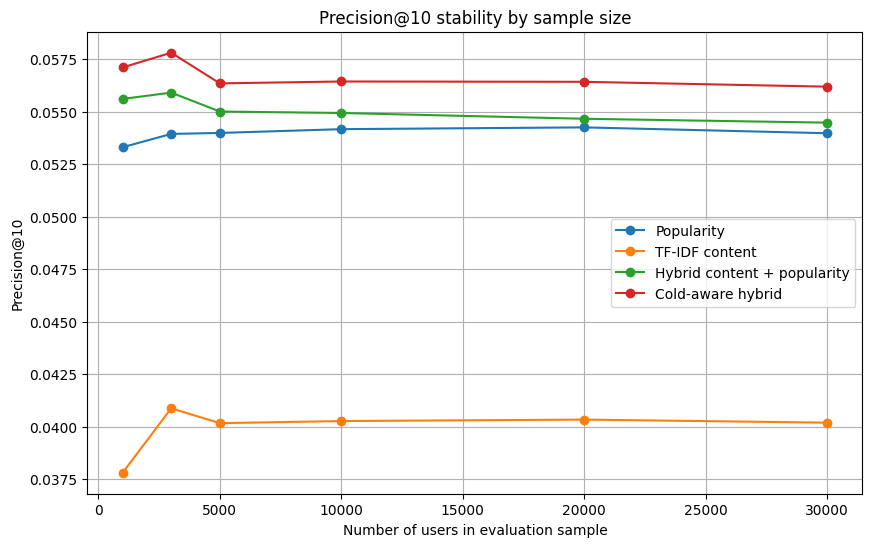

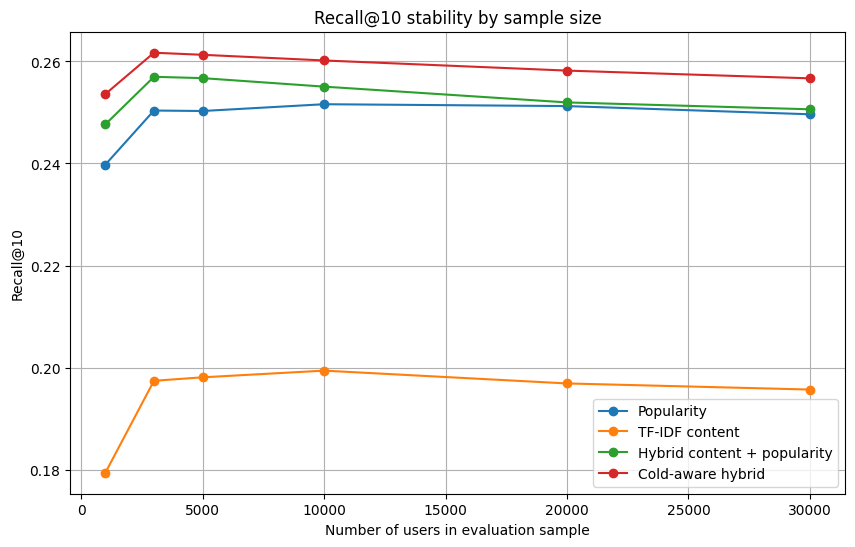

In [ ]:
plt.figure(figsize=(10, 6))

for model_name in stability_df["model"].unique():
    tmp = stability_df[stability_df["model"] == model_name]
    plt.plot(
        tmp["n_users_sample"],
        tmp[f"precision@{K}"],
        marker="o",
        label=model_name
    )

plt.xlabel("Number of users in evaluation sample")
plt.ylabel(f"Precision@{K}")
plt.title(f"Precision@{K} stability by sample size")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))

for model_name in stability_df["model"].unique():
    tmp = stability_df[stability_df["model"] == model_name]
    plt.plot(
        tmp["n_users_sample"],
        tmp[f"recall@{K}"],
        marker="o",
        label=model_name
    )

plt.xlabel("Number of users in evaluation sample")
plt.ylabel(f"Recall@{K}")
plt.title(f"Recall@{K} stability by sample size")
plt.legend()
plt.grid(True)
plt.show()

### Интерпретация результатов

Наиболее заметное изменение метрик наблюдается при увеличении размера выборки с 1000 до 3000 пользователей.

Начиная примерно с 5000 пользователей значения Precision@10 и Recall@10 становятся стабильными, а дальнейшее увеличение объёма выборки до 10000–30000 пользователей практически не влияет на порядок моделей и величину метрик.

Это свидетельствует о том, что выборка из 5000 пользователей является достаточно репрезентативной для дальнейшей оценки рекомендательных алгоритмов.

## 8. Bootstrap-анализ доверительных интервалов

In [12]:
models_for_validation = {
    "Popularity": recommend_popularity,
    "TF-IDF content": recommend_tfidf_content,
    "Hybrid content + popularity": recommend_hybrid_content_popularity,
    "Cold-aware hybrid": recommend_cold_aware_hybrid,
}

In [24]:
# Один раз предсчитываем рекомендации для каждой модели

eval_users_all = get_eval_sample(
    test["user_id"].unique(),
    n=5000,
    seed=RANDOM_STATE
)

precomputed_recs = {}

for model_name, func in models_for_validation.items():
    print("Precompute:", model_name)

    model_recs = {}

    for i, user_id in enumerate(eval_users_all):
        if i % 1000 == 0:
            print(i, "/", len(eval_users_all))

        model_recs[user_id] = func(user_id, k=K)

    precomputed_recs[model_name] = model_recs

Precompute: Popularity
0 / 5000
1000 / 5000
2000 / 5000
3000 / 5000
4000 / 5000
Precompute: TF-IDF content
0 / 5000
1000 / 5000
2000 / 5000
3000 / 5000
4000 / 5000
Precompute: Hybrid content + popularity
0 / 5000
1000 / 5000
2000 / 5000
3000 / 5000
4000 / 5000
Precompute: Cold-aware hybrid
0 / 5000
1000 / 5000
2000 / 5000
3000 / 5000
4000 / 5000


In [25]:
def evaluate_precomputed(model_recs, test_grouped, users_sample, k=10):
    precisions = []
    recalls = []

    for user_id in users_sample:
        true_items = test_grouped.get(user_id)
        recs = model_recs.get(user_id, [])[:k]

        if true_items is None:
            continue

        hit_count = len(set(recs) & set(true_items))

        precisions.append(hit_count / k)
        recalls.append(hit_count / len(set(true_items)))

    return {
        f"precision@{k}": np.mean(precisions),
        f"recall@{k}": np.mean(recalls),
        "n_users": len(precisions)
    }


def bootstrap_precomputed(model_recs, test_grouped, users_pool, n_users=5000, n_bootstrap=50, k=10, random_state=42):
    rng = np.random.default_rng(random_state)
    users_pool = np.array(list(users_pool))

    rows = []

    for b in range(n_bootstrap):
        sample_users = rng.choice(
            users_pool,
            size=min(n_users, len(users_pool)),
            replace=True
        )

        res = evaluate_precomputed(
            model_recs=model_recs,
            test_grouped=test_grouped,
            users_sample=sample_users,
            k=k
        )

        rows.append({
            "bootstrap_iter": b,
            f"precision@{k}": res[f"precision@{k}"],
            f"recall@{k}": res[f"recall@{k}"],
            "n_users": res["n_users"]
        })

    return pd.DataFrame(rows)

In [30]:
bootstrap_results = []

for model_name, model_recs in precomputed_recs.items():
    print("Bootstrap:", model_name)

    boot_df = bootstrap_precomputed(
        model_recs=model_recs,
        test_grouped=test_grouped,
        users_pool=eval_users_all,   # ВАЖНО: не test_users
        n_users=5000,
        n_bootstrap=50,
        k=K,
        random_state=RANDOM_STATE
    )

    boot_df["model"] = model_name
    bootstrap_results.append(boot_df)

bootstrap_df = pd.concat(bootstrap_results, ignore_index=True)

display(bootstrap_df.head())

Bootstrap: Popularity
Bootstrap: TF-IDF content
Bootstrap: Hybrid content + popularity
Bootstrap: Cold-aware hybrid


,bootstrap_iter,precision@10,recall@10,n_users,model
0,0,0.05494,0.253247,5000,Popularity
1,1,0.05472,0.254332,5000,Popularity
2,2,0.05504,0.261387,5000,Popularity
3,3,0.05512,0.247598,5000,Popularity
4,4,0.05248,0.244002,5000,Popularity


In [31]:
def ci_low(x):
    return np.percentile(x, 2.5)


def ci_high(x):
    return np.percentile(x, 97.5)


bootstrap_summary = (
    bootstrap_df
    .groupby("model")
    .agg(
        precision_mean=(f"precision@{K}", "mean"),
        precision_std=(f"precision@{K}", "std"),
        precision_ci_low=(f"precision@{K}", ci_low),
        precision_ci_high=(f"precision@{K}", ci_high),
        recall_mean=(f"recall@{K}", "mean"),
        recall_std=(f"recall@{K}", "std"),
        recall_ci_low=(f"recall@{K}", ci_low),
        recall_ci_high=(f"recall@{K}", ci_high),
    )
    .reset_index()
)

display(
    bootstrap_summary
    .sort_values("precision_mean", ascending=False)
)

,model,precision_mean,precision_std,precision_ci_low,precision_ci_high,recall_mean,recall_std,recall_ci_low,recall_ci_high
0,Cold-aware hybrid,0.056372,0.001081,0.054313,0.058122,0.261203,0.005766,0.250424,0.271021
1,Hybrid content + popularity,0.055102,0.001098,0.053184,0.056944,0.256922,0.005497,0.245487,0.266018
2,Popularity,0.054004,0.001047,0.051995,0.055595,0.250091,0.005595,0.239634,0.259211
3,TF-IDF content,0.040234,0.000955,0.038428,0.041902,0.197910,0.004970,0.186747,0.206237


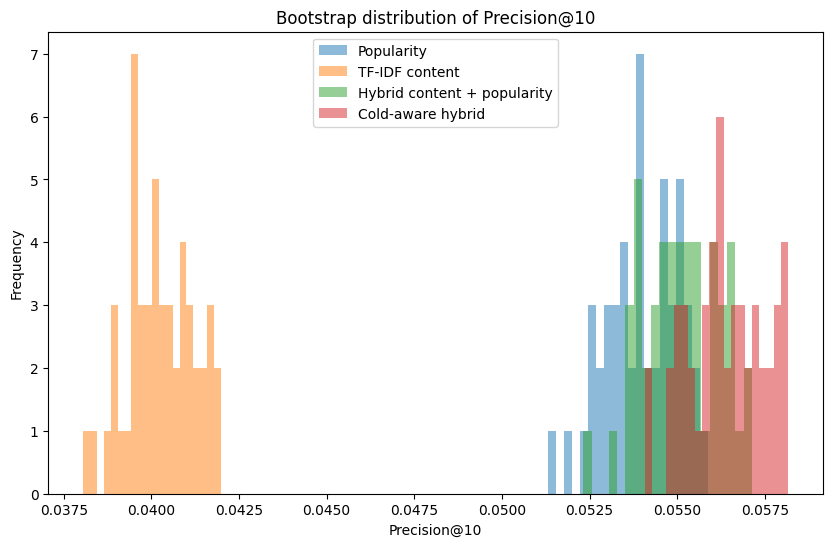

In [32]:
plt.figure(figsize=(10, 6))

for model_name in bootstrap_df["model"].unique():
    tmp = bootstrap_df[bootstrap_df["model"] == model_name]
    plt.hist(
        tmp[f"precision@{K}"],
        bins=20,
        alpha=0.5,
        label=model_name
    )

plt.xlabel(f"Precision@{K}")
plt.ylabel("Frequency")
plt.title(f"Bootstrap distribution of Precision@{K}")
plt.legend()
plt.show()

### Интерпретация bootstrap-анализа

Bootstrap позволяет оценить устойчивость метрик качества относительно случайного выбора пользователей в evaluation sample.

Если доверительные интервалы моделей существенно пересекаются, различия между моделями могут быть статистически незначимыми. Если интервалы не пересекаются или пересекаются незначительно, можно говорить о более устойчивом преимуществе одной модели над другой.

Таким образом, bootstrap-анализ используется как дополнительная проверка надёжности полученных результатов.

In [33]:
summary_table = pd.DataFrame({
    "Metric": [
        "Users",
        "Items",
        "Interactions",
        "Train interactions",
        "Test interactions",
        "Train users",
        "Test users",
        "Train items",
        "Test items",
        "Density (%)",
        "Sparsity (%)",
        "Full cold users",
        "Full cold users share (%)",
        "Very cold users (1-2)",
        "Semi-cold users (3-5)",
        "Medium users (6-9)",
        "Warm users (10+)",
        "Cold items",
        "Cold items share (%)"
    ],
    "Value": [
        interactions["user_id"].nunique(),
        interactions["item_id"].nunique(),
        len(interactions),

        len(train),
        len(test),

        train["user_id"].nunique(),
        test["user_id"].nunique(),

        train["item_id"].nunique(),
        test["item_id"].nunique(),

        round(
            100 * len(interactions)
            / (
                interactions["user_id"].nunique()
                * interactions["item_id"].nunique()
            ),
            4
        ),

        round(
            100
            * (
                1
                - len(interactions)
                / (
                    interactions["user_id"].nunique()
                    * interactions["item_id"].nunique()
                )
            ),
            4
        ),

        len(full_cold_users),

        round(
            100
            * len(full_cold_users)
            / test["user_id"].nunique(),
            2
        ),

        len(very_cold_users),
        len(semi_cold_users),
        len(medium_users),
        len(warm_users),

        len(cold_items),

        round(
            100
            * len(cold_items)
            / test["item_id"].nunique(),
            2
        )
    ]
})

display(summary_table)

,Metric,Value
0,Users,9.621790e+05
1,Items,1.570600e+04
2,Interactions,5.476251e+06
3,Train interactions,4.423600e+06
4,Test interactions,1.052651e+06
5,Train users,8.193090e+05
6,Test users,3.123270e+05
7,Train items,1.533100e+04
8,Test items,8.863000e+03
9,Density (%),3.620000e-02


## Итоговый вывод по экспериментальному дизайну

В рамках подготовки экспериментов была построена схема оценки рекомендательных моделей, максимально приближенная к реальному сценарию работы онлайн-кинотеатра.

Для разделения данных использовался временной сплит по признаку `last_watch_dt`, что позволяет обучать модели на прошлых взаимодействиях пользователей и оценивать их способность предсказывать будущие просмотры.

Анализ показал наличие выраженной проблемы холодного старта:

- около 45% пользователей тестовой выборки являются full cold users;
- значительная часть остальных пользователей имеет короткую историю взаимодействий;
- в тестовой выборке присутствуют cold items.

Дополнительно была проведена проверка устойчивости метрик на различном числе пользователей. Полученные результаты показали, что после 5000 пользователей значения Precision@10 и Recall@10 практически выходят на плато. Следовательно, выборка из 5000 пользователей является репрезентативной для дальнейшего сравнения моделей.

Bootstrap-анализ позволяет дополнительно оценить устойчивость получаемых метрик и доверительные интервалы качества моделей.

Таким образом, построенная экспериментальная схема обеспечивает корректное и статистически обоснованное сравнение рекомендательных алгоритмов в условиях выраженной проблемы холодного старта.

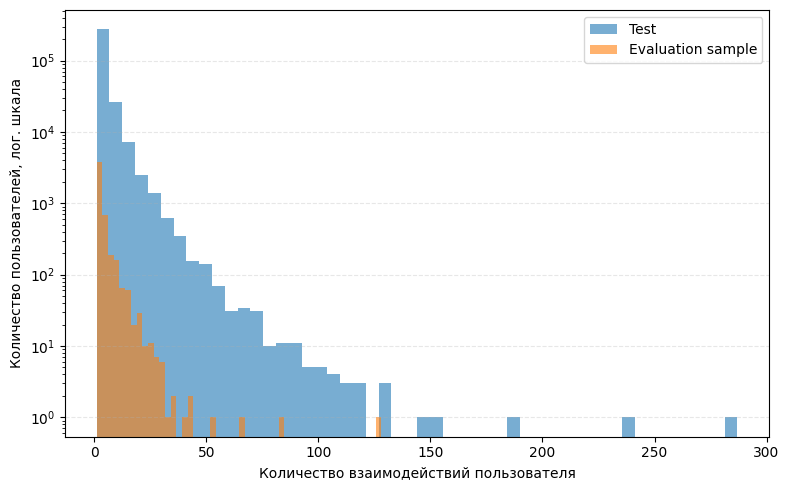

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

# Истории пользователей в test
test_activity = test.groupby("user_id").size()

# Evaluation sample на 5000 пользователей
eval_users = np.random.choice(
    test["user_id"].unique(),
    size=5000,
    replace=False
)

eval_activity = test[test["user_id"].isin(eval_users)].groupby("user_id").size()

plt.figure(figsize=(8, 5))

plt.hist(test_activity, bins=50, alpha=0.6, label="Test")
plt.hist(eval_activity, bins=50, alpha=0.6, label="Evaluation sample")

plt.yscale("log")
plt.xlabel("Количество взаимодействий пользователя")
plt.ylabel("Количество пользователей, лог. шкала")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_sample.png", dpi=300, bbox_inches="tight")
plt.show()